# Day 3 — Classifier v2: LightGBM + class-imbalance handling

Replaces the Day 2 Logistic Regression baseline with a gradient-boosted tree model, and corrects for the 3.5% fraud imbalance that the baseline ignored. Evaluated against the **exact same locked holdout** as Day 2, so results are directly comparable.

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    confusion_matrix, classification_report, precision_recall_curve
)

from src.data import load_merged_train
from src.features import get_feature_lists
from src.split import apply_locked_split
from src.model import build_lgbm_pipeline

RANDOM_STATE = 42

In [2]:
train_full = load_merged_train()

train_df, holdout_df = apply_locked_split(train_full)
print('train:', train_df.shape, 'holdout:', holdout_df.shape)

numeric_features, categorical_features = get_feature_lists(train_full)

X_train = train_df[numeric_features + categorical_features]
y_train = train_df['isFraud']
X_holdout = holdout_df[numeric_features + categorical_features]
y_holdout = holdout_df['isFraud']

print('train fraud rate:', y_train.mean().round(4), '| holdout fraud rate:', y_holdout.mean().round(4))

train: (472432, 434) holdout: (118108, 434)
train fraud rate: 0.035 | holdout fraud rate: 0.035


## Imbalance handling: class weighting, not SMOTE

`class_weight='balanced'` tells the model to weight each fraud example more heavily during training (inversely proportional to how rare fraud is), instead of generating synthetic fraud examples like SMOTE would. Chosen over SMOTE because it doesn't fabricate data points that never happened — simpler to defend, and tree models handle re-weighting natively without needing a separate resampling step.

In [3]:
model = build_lgbm_pipeline(numeric_features, categorical_features, random_state=RANDOM_STATE)

model.fit(X_train, y_train)
print('Fitted.')

Fitted.


In [4]:
y_proba = model.predict_proba(X_holdout)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

precision = precision_score(y_holdout, y_pred)
recall = recall_score(y_holdout, y_pred)
f1 = f1_score(y_holdout, y_pred)
pr_auc = average_precision_score(y_holdout, y_proba)

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print()
print(classification_report(y_holdout, y_pred, target_names=['not fraud', 'fraud']))

Precision: 0.2745
Recall:    0.8321
F1:        0.4128
PR-AUC:    0.6900

              precision    recall  f1-score   support

   not fraud       0.99      0.92      0.96    113975
       fraud       0.27      0.83      0.41      4133

    accuracy                           0.92    118108
   macro avg       0.63      0.88      0.68    118108
weighted avg       0.97      0.92      0.94    118108



Confusion matrix (rows=actual, cols=predicted):
[[104886   9089]
 [   694   3439]]


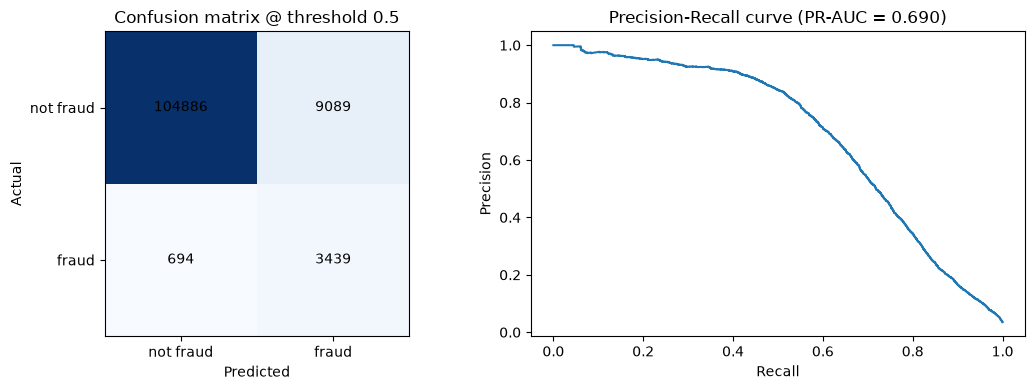

In [5]:
cm = confusion_matrix(y_holdout, y_pred)
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['not fraud', 'fraud'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['not fraud', 'fraud'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion matrix @ threshold 0.5')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center')

prec_curve, rec_curve, _ = precision_recall_curve(y_holdout, y_proba)
axes[1].plot(rec_curve, prec_curve)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall curve (PR-AUC = {pr_auc:.3f})')

plt.tight_layout()
plt.show()

## Compare against the Day 2 baseline

In [6]:
with open('../results/baseline_metrics.json') as f:
    baseline = json.load(f)

comparison = pd.DataFrame([
    {
        'model': baseline['model'],
        'precision': baseline['precision'],
        'recall': baseline['recall'],
        'f1': baseline['f1'],
        'pr_auc': baseline['pr_auc'],
    },
    {
        'model': 'LightGBM (class_weight=balanced)',
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': pr_auc,
    },
]).set_index('model')

comparison

,precision,recall,f1,pr_auc
model,,,,
"LogisticRegression (baseline, no imbalance handling)",0.815712,0.268812,0.404368,0.471149
LightGBM (class_weight=balanced),0.274505,0.832083,0.412820,0.690047


## Save metrics

In [7]:
metrics = {
    'model': 'LightGBM (class_weight=balanced)',
    'threshold': 0.5,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'pr_auc': pr_auc,
    'confusion_matrix': cm.tolist(),
    'n_train': len(X_train),
    'n_holdout': len(X_holdout),
}

with open('../results/classifier_v2_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved to results/classifier_v2_metrics.json')
metrics

Saved to results/classifier_v2_metrics.json


{'model': 'LightGBM (class_weight=balanced)',
 'threshold': 0.5,
 'precision': 0.2745051085568327,
 'recall': 0.8320832325187515,
 'f1': 0.4128203589220335,
 'pr_auc': 0.6900468809788434,
 'confusion_matrix': [[104886, 9089], [694, 3439]],
 'n_train': 472432,
 'n_holdout': 118108}

In [8]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/classifier_v2.joblib')
print('Saved fitted model to models/classifier_v2.joblib')

Saved fitted model to models/classifier_v2.joblib


## Takeaway

_Fill in after running: how much recall improved vs. the Day 2 baseline, and at what cost to precision. This is not the final model — Day 4 still needs to pick a cost-based decision threshold instead of the default 0.5 used here._